In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tifffile 
import math
from scipy import ndimage
from scipy.interpolate import RegularGridInterpolator


## crop script

In [2]:
path_gt_sino = "S.tif"
path_trace = "Tr.tif"
path_ma_sino = "Sma.tif"

gt_sino = tifffile.imread(path_gt_sino).astype(np.float32)
trace   = tifffile.imread(path_trace).astype(np.float32)
ma_sino = tifffile.imread(path_ma_sino).astype(np.float32)


In [3]:
print(gt_sino.min(), gt_sino.max())
print(trace.min(), trace.max())
print(ma_sino.min(), ma_sino.max())

-0.00078007596 2.6220136
0.0 1.0345163
-0.0009226138 4.795466


In [4]:
mat = []
spec = []
with open("material.txt", "r+") as f:
    # Reading from a file
    for line in f:
        a, b = [float(x) for x in line[:-1].split(' ')]
        #print(a, b)
        mat.append([a*1000, b])
with open("spectra.txt", "r+") as f:
    # Reading from a file
    for line in f:
        a, b = [float(x) for x in line[:-1].split(' ')]
        print(a, b)
        spec.append([a, b])
mat  = np.array(mat)
spec = np.array(spec)
mat_interp = RegularGridInterpolator((mat[:,0],), mat[:,1])
mat_grid = np.array([mat_interp([x]) for x in list(spec[:,0])])

1.5 75084043.32338229
2.5 41917170.326185696
3.5 44638379.56434863
4.5 61949914.09828081
5.5 87669845.31260288
6.5 119900987.33834527
7.5 223634527.55493236
8.5 1776089665.2278535
9.5 1774391203.5929248
10.5 147520565.4025899
11.5 213022169.64519757
12.5 83633619.09624048
13.5 89796553.48144448
14.5 101334848.16329975
15.5 112962006.33288543
16.5 124315524.58732587
17.5 135085593.49813536
18.5 145175752.645837
19.5 154329132.68321332
20.5 162462502.02786705
21.5 169524831.2647073
22.5 175476524.94244194
23.5 180332572.3030801
24.5 184098656.71151382
25.5 186875924.18663195
26.5 188735222.09160697
27.5 189722320.89449432
28.5 189922269.29322028
29.5 189428859.4521338
30.5 188342902.7212146
31.5 186745869.4434661
32.5 184705172.92121089
33.5 182285617.8625945
34.5 179557027.58913866
35.5 176574172.796793
36.5 173388505.62863106
37.5 170039212.49067563
38.5 166575581.68016282
39.5 163028031.83812454
40.5 159419348.41569692
41.5 155772014.46917427
42.5 152108238.87070295
43.5 148451617.212

In [7]:
ma_generated = np.zeros_like(ma_sino)
rho = 0.4505
total_sum = 0
for i in range(mat_grid.shape[0]):
    total_sum += spec[i, 1]
    lin = trace * mat_grid[i] / rho + gt_sino
    ma_generated += spec[i, 1] * np.exp(-lin)
ma_generated = -np.log(ma_generated/total_sum)
Sma = Image.fromarray(ma_generated)
Sma.save('../generated/Sma_gen/sma.tif')
print(ma_generated.min(), ma_generated.max())

-0.00077992055 5.076116


-1.4280784 0.066982985


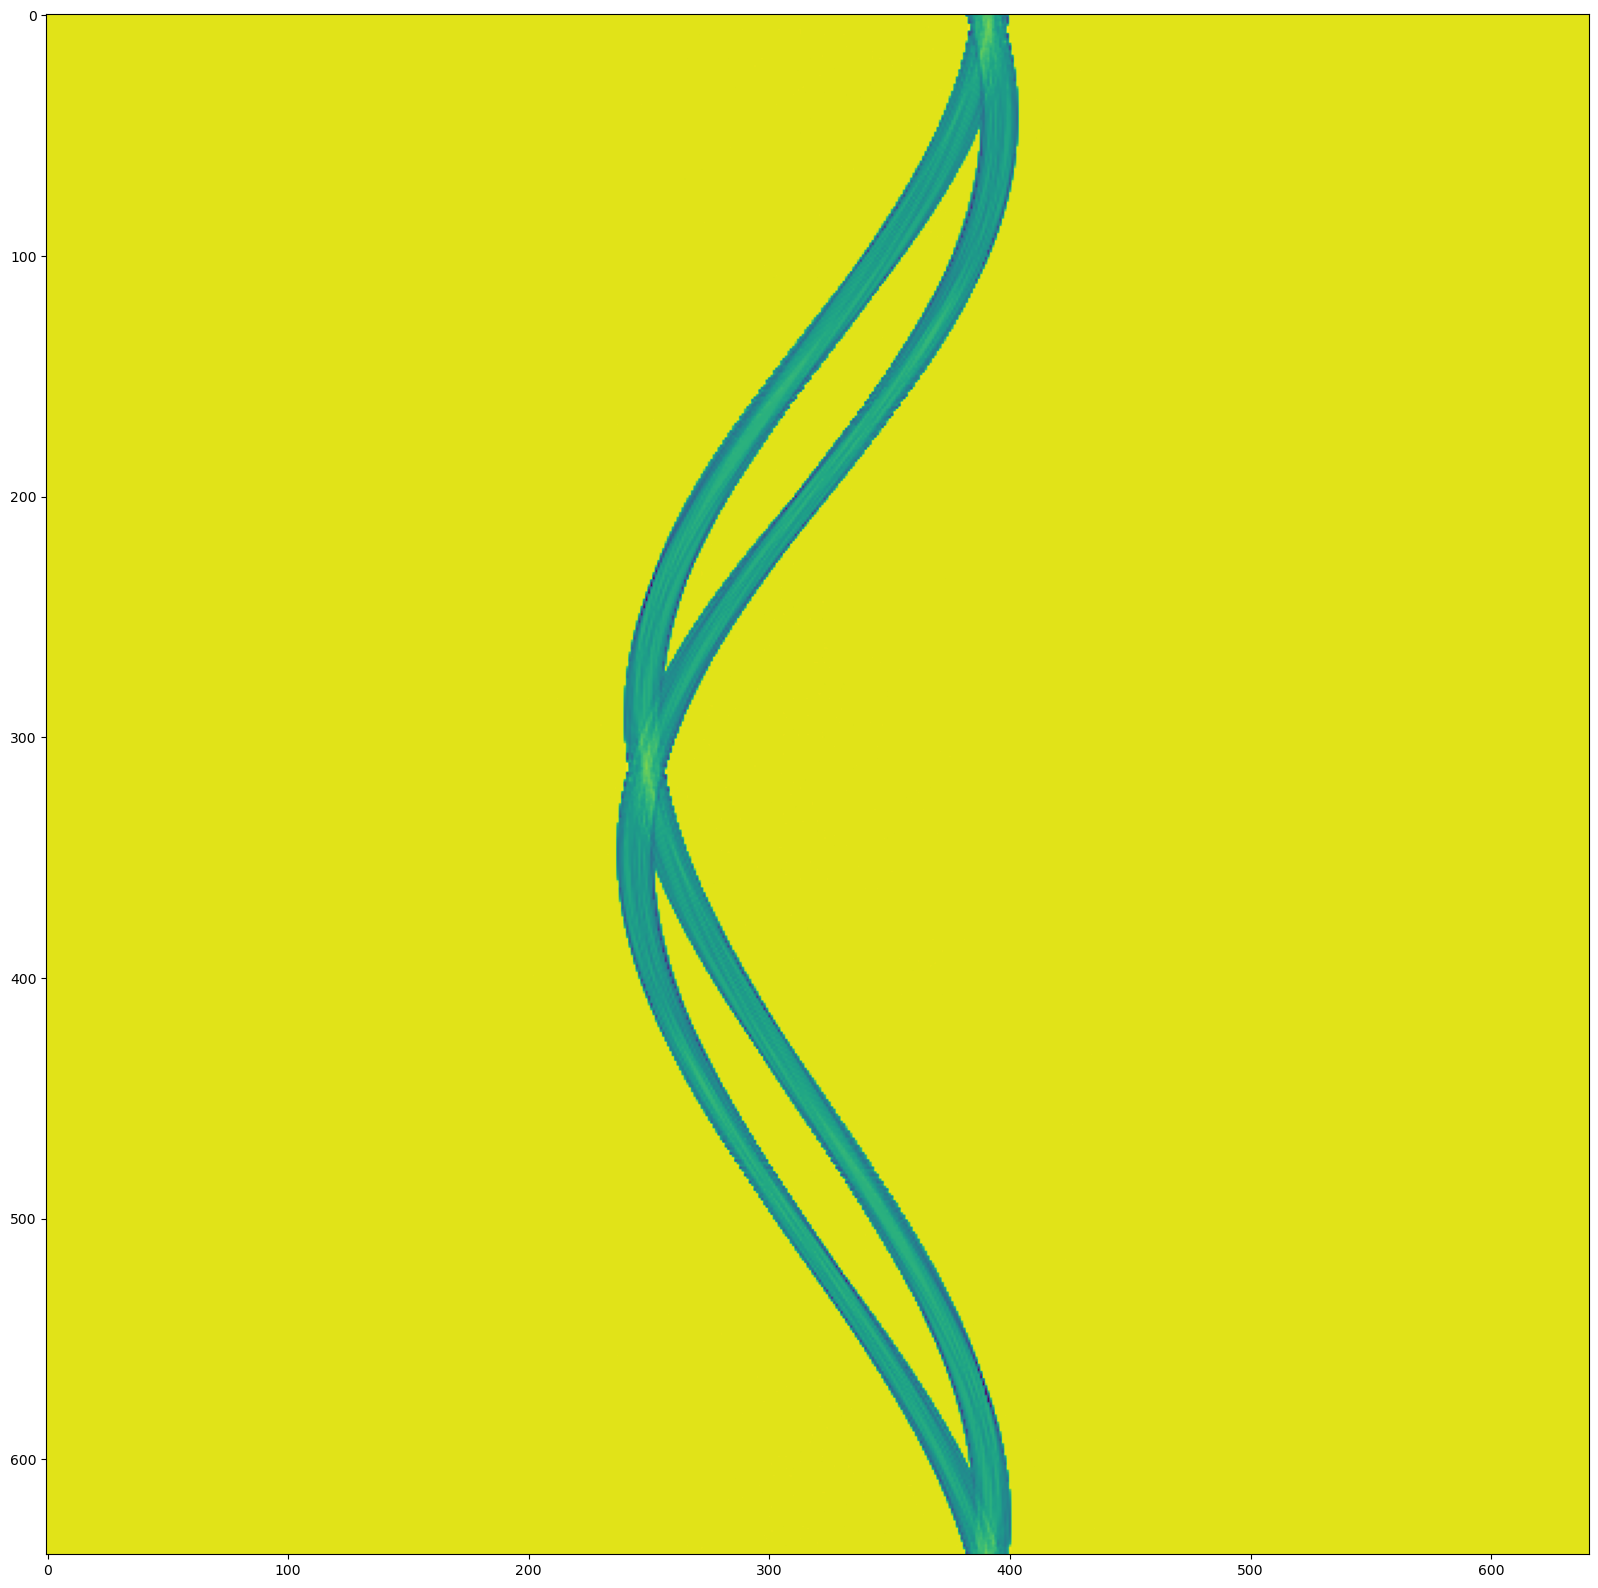

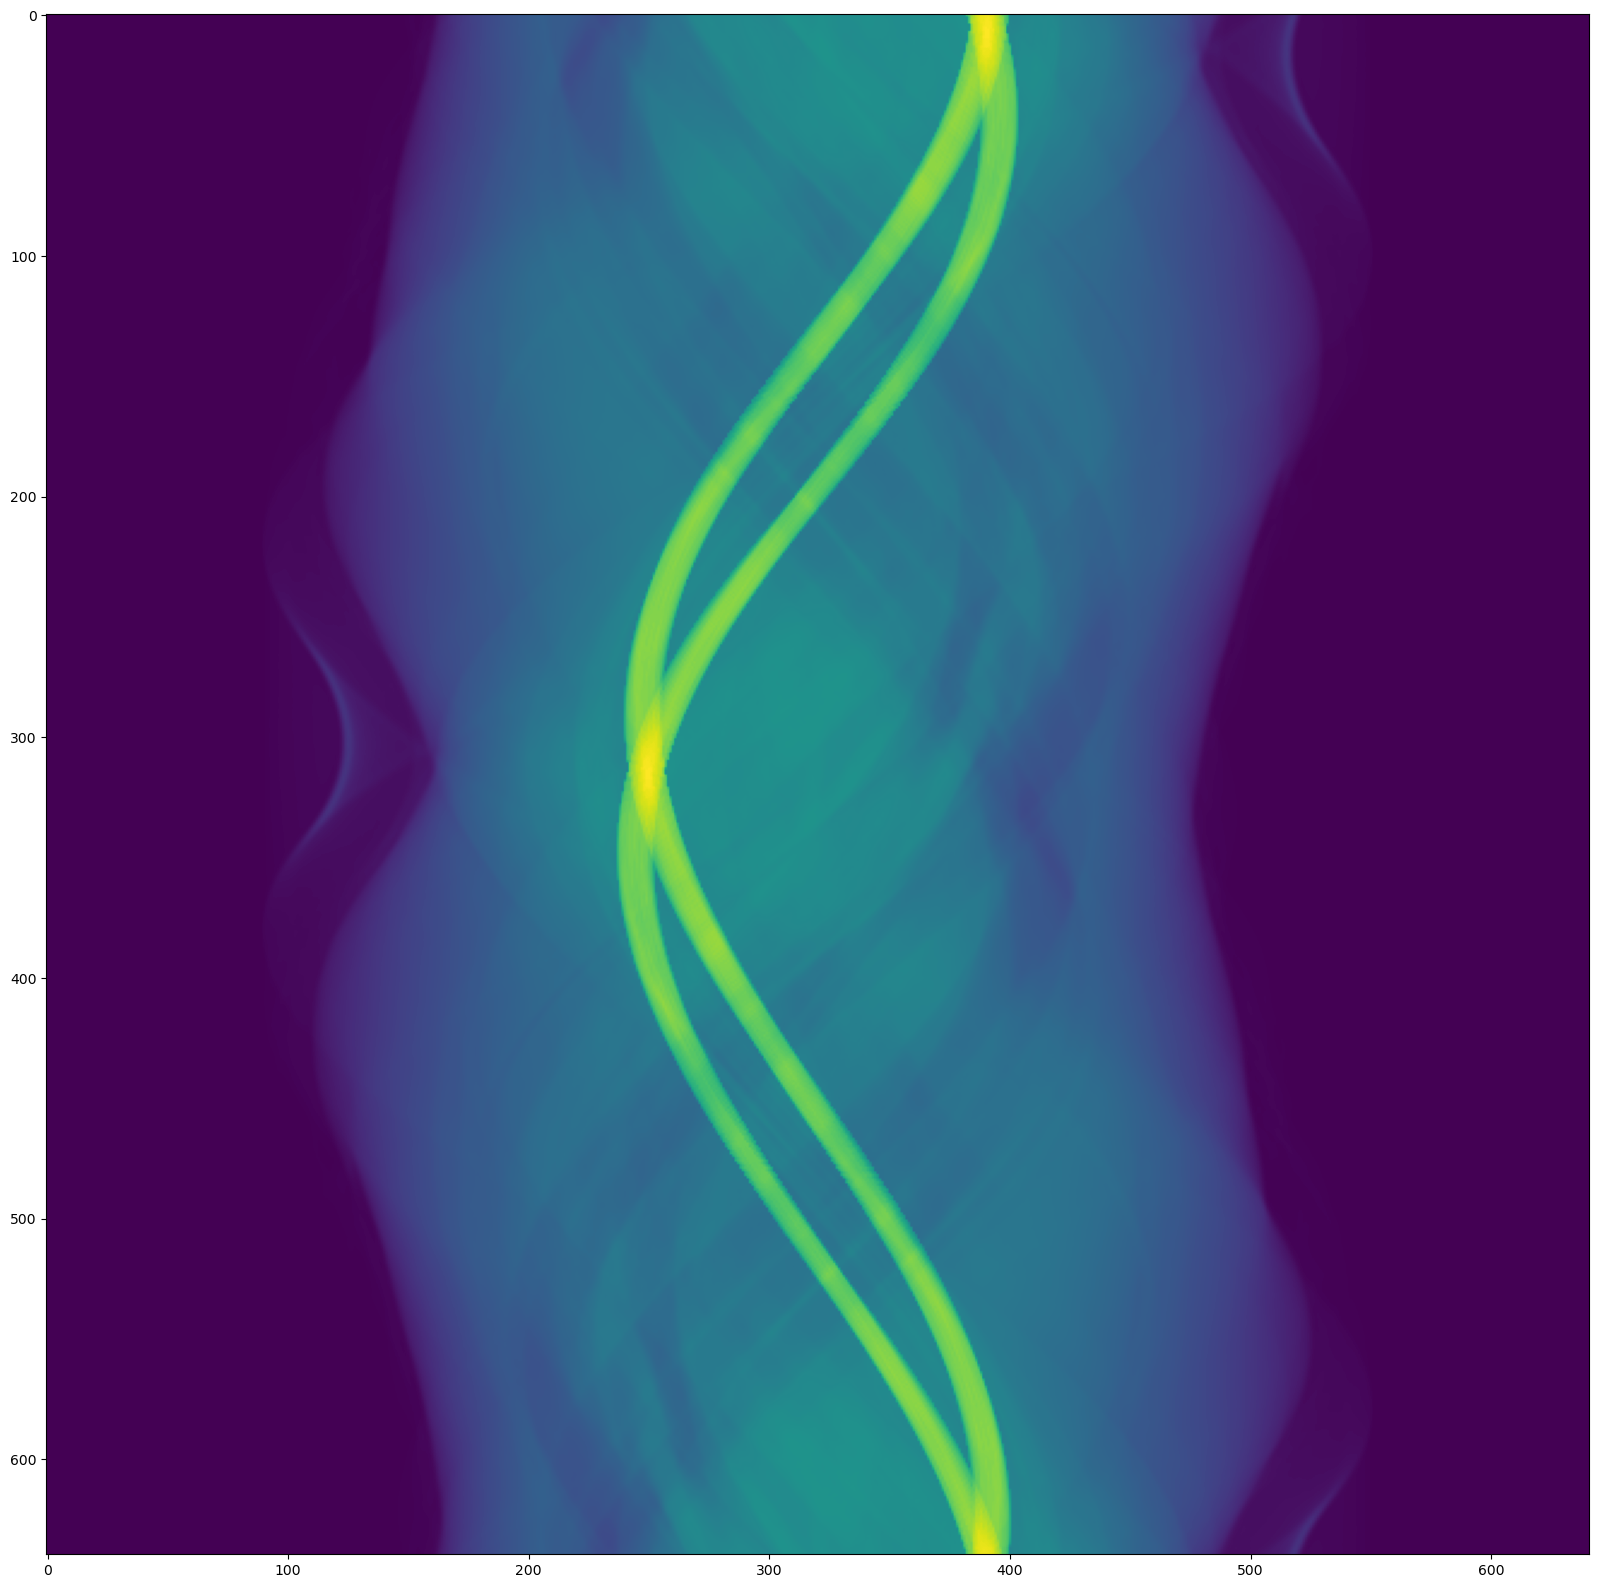

In [6]:
dif = ma_sino - ma_generated
print(dif.min(), dif.max())
plt.figure(figsize = (20,20))
plt.imshow(ma_sino - ma_generated)
plt.show()
plt.figure(figsize = (20,20))
plt.imshow(ma_generated)
plt.show()